# MPhil DIS: S1 Coursework 2025/26

*Matt Kenzie*

## The Problem

Your college room mate is a Physics student having some trouble with data analysis. 

They have been asked by their supervisor to determine the performance of a photon detector in their lab. 

Your friend has diligently collected calibration samples in the lab. They have used a laser setup to produce single photons at known fixed Energies (i.e. frequencies) of $E_0$ = [20, 30, 40, 50, 60, 70, 80] GeV and recorded the measured energy, $E$, of the detector (also in GeV, although the units are irrelevant for this problem). They performed $N=1000$ measurements of the energy recorded by the detector, $E$, at each fixed point $E_0$. (Hint: we may assume the supervisor’s lab setup is so sophisticated that the energy uncertainty of the laser itself is negligible - in other words $E_0$ is known exactly with no error). 

Your friend knows, because they asked ChatGPT, that the measured energy (registered by the detection device),
$E$, will be normally distributed, $E\sim \mathcal{N}(\mu_E, \sigma^2_E)$, with mean, 

$$
\mu_E = \lambda E_0 + \Delta, \tag{1}
$$

and a width, $\sigma_E$, given by

$$
\left( \frac{\sigma_E}{E_0} \right)^2 = \left( \frac{a}{\sqrt{E_0}} \right)^2 + \left( \frac{b}{E_0} \right)^2 + c^2. \tag{2}
$$

Your task is to use the input data provided in `sample.csv` (which contains two columns corresponding to the laser energy, $E_0$, and the measured energy, $E$) to provide estimates of the parameters $\{ \lambda, \Delta, a, b, c\}$

## 0) Importing Modules


In [1]:
#importing modules
import matplotlib.pyplot as plt
import os
from s1_sol import main

main.set_mpl_style()
df = main.load_data()

Style applied


## 1) Plotting Sample Estimates
**10 marks**


### 1(i) Plot Total Sample

Below a histogram is plotted showing the distribution of residuals of energy measurements from the calibration experiment. This is defined as the difference between the energy the detector measured for each photon, $E$, and its actual associated energy value, $E_0$. 
$$
Residual = E - E_0 \tag{3}
$$
This distribution allows us to get a general view of how well the detector is calibrated.

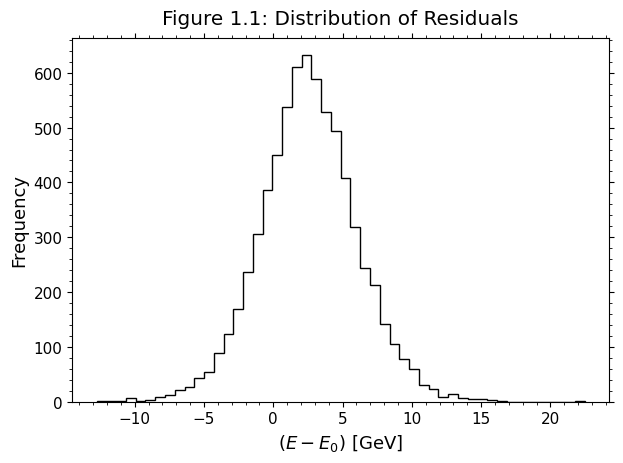

In [2]:
from s1_sol import q1

fig, ax = q1.plot_total_hist(df)

os.system("mkdir -p ../figs")
fig.savefig("../figs/Figure1.1.pdf")

- The plot above shows a fairly symmetric bell-shaped distribution, consistent with the suggestion that $E$ is normally distributed. 
- The distribution has a significant width, with measurements ranging from around 13 GeV below the actual photon energy to 22 GeV above. 
- The bulk of measurements appear to lie above zero, with the peak at around 2.5 GeV.
- This suggests the detector has a systematic positive bias in its measurements, and because there is only one peak its likely this is fairly consistent.

### 1(ii) Overlay Samples at each $E_0$

The graph below plots a histogram distribution of $E - E_0$ for each value of $E_0$, breaking down how the detectors performance changes with energy. Each histogram is coloured on the 'viridis' scale for easy identification of each $E_0$ whilst simultaneously giving an idea of the change in distribution across the energy levels.

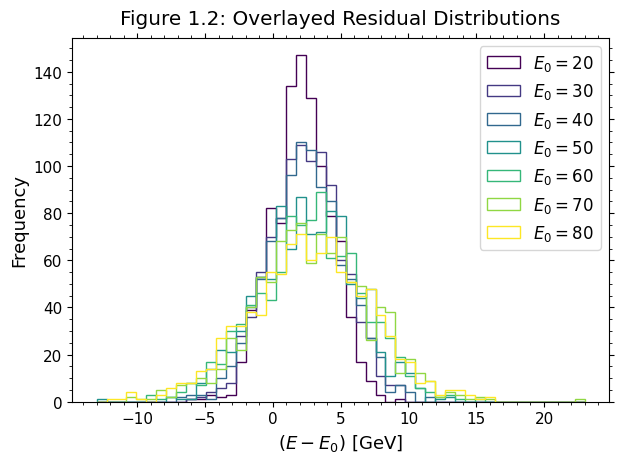

In [3]:
fig = q1.plot_overlapping_hist(df)

fig.savefig("../figs/Figure1.2.pdf")

- All of the distributions appear to follow similar symmetric bell-curve shapes to the total distribution above, suggesting all continue to follow a normal distribution.
- The width of the distributions clearly increases with energy, the 20 GeV purple histogram is sharp and narrow with a range of 15 GeV and a max frequency over 140, where as the 80 GeV histogram is broader and flatter with a range of 28 GeV and a frequency peak just under 80.
- This suggests the detectors resolution, $\sigma_E$, reduces as $E_0$ increases.
- The distributions at all $E_0$ values are centered to the right of 0 GeV, with the peaks sitting within the 0 - 5 GeV range, further confirming the detectors systematic positive bias.
- The higher energy distributions appear slightly further to the right than the lower energy ones, suggesting the bias is not constant and instead aligns with the equation, $\mu_E = \lambda E_0 + \Delta$, where $\lambda > 1$.


### 1(iii) Sample Estimates
In this step the measured energy values $E$ are grouped by their associated $E_0$. The sample mean, $\hat{\mu}_{samp}$ and sample standard deviation, $\hat{\sigma}_{\rm samp}$ are calculated using the following equations:

$$
\hat{\mu}_{\rm samp} = \frac{1}{N} \sum_{i=1}^{N} E_{i} \tag{4}
$$
$$
\hat{\sigma}_{\rm samp} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (E_{i} - \hat{\mu}_{\rm samp})^{2}} \tag{5}
$$.

Then the uncertainties for each of estimates are calculated using the equations below.
$$
\sigma_{\hat{\mu}} = \frac{\hat{\sigma}_{\rm samp}}{\sqrt{N}} \tag{6}
$$

$$
\sigma_{\hat{\sigma}} = \frac{\hat{\sigma}_{\rm samp}}{\sqrt{2(N-1)}} \tag{7}
$$

With these values the following graphs are plotted showing the sample mean, and sample variance over $E_0$.


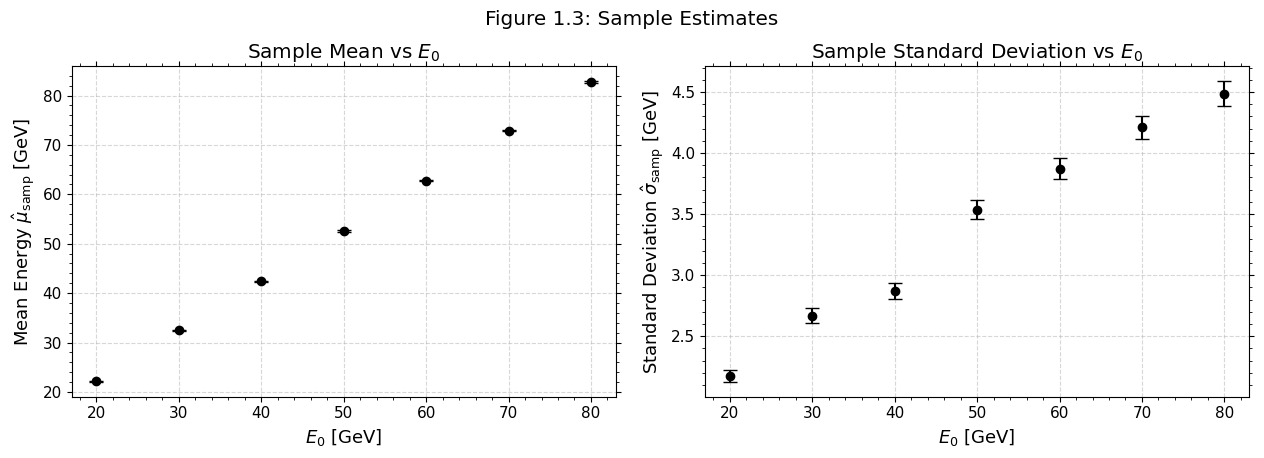

In [4]:
fig, values = q1.calculate_and_plot_sample_estimates(df)
fig.savefig("../figs/Figure1.3.pdf")

- The sample mean plot shows a linear correlation between $E_0$ and $\hat{\mu}_{\rm samp}$, and as the points all sit above the $ y = x $ line, this confirms the linear model $\mu_E = \lambda E_0 + \Delta $.
- The uncertainties of the samples means are extremely small on the graph (almost invisible), suggesting high precision due to the large sample size of 1000 repeats per $E_0$.
- The right-hand plot also shows a clear increase in $\hat{\sigma}_{\rm samp}$ as $E_0$ increases. This relationship appears less linear than in the left-hand graph and so could follow the non-linear equation for $\sigma_{E}$ described in the introduction.
- The error-bars on the standard deviation plots are far larger than on the samples means plot, an expected effect due to the standard deviations being a factor of 10 smaller than the means, whilst the associated uncertainties are only decreased by a factor of around ${\sqrt{2}}$.


### 1(iv) fit trends

In this section the calibration parameters, $\{\lambda, \Delta, a, b, c\}$, are determined using 'Least Squares' to fit *Eq. 1* to the sample means and *Eq. 2* to the sample standard deviations.

For more accesible viewing, similar graphs have been plotted to the previous step, except the y-axes have been scaled to $\hat{\mu}_{\rm samp} - E_0$ and $\hat{\sigma}_{\rm samp} / E_0$. This allows for clearer viewing of deviations and the relative performance of each fit. The best-fit curves have been overlayed onto each graph alongside error bands from the 16th to the 84th percentile, calculated using parametric bootstrapping based on the covariance matrix.

The resulting values and associated uncertainties for each of the parameters are printed below and saved to the `results.json` file.

Fitted parameter values:
λ = 1.012 ± 0.002
Δ = 1.964 ± 0.087
a = 0.387 ± 0.060
b = 1.127 ± 0.376
c = 0.034 ± 0.008 

Saved to 'results.json'


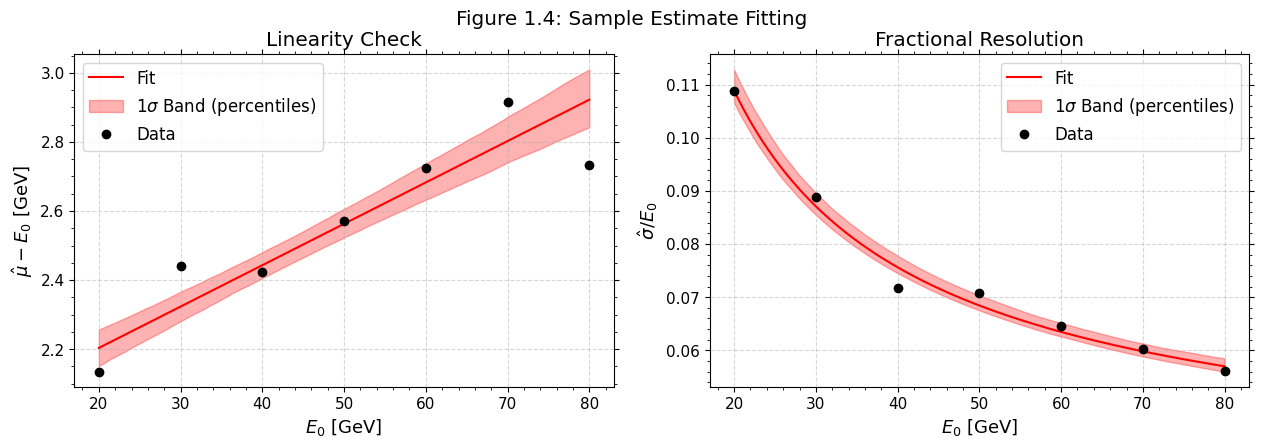

In [5]:
fig = q1.least_squares_fit_and_plot(values, "sample_ests","Figure 1.4: Sample Estimate Fitting")

fig.savefig("../figs/Figure1.4.pdf")

- The systematic offset value of $\Delta$ has been determined to be around 1.96, confirming the positive bias noted in the previous sections. The left-hand graph also supports this as it is clear to see if we extrapolate the fit to the left it would have a positive y-intercept.
- The value of $\lambda$ also sits just above unity, confirming bias does increase with $E_0$ as was suggested from *Fig. 1.2*, with the higher energy distributions sitting slightly further to the right. This is further confirmed by the positive gradient in the left-hand graph above.
- The right-hand graph shows the fractional resolution drops steeply at lower energies and becomes less steep at higher energies. The fit tells us that the detector is, relatively, more precise at higher energy levels, its error drops from 11% at 20 GeV to just under 6% at 80 GeV.
- Both of the fits in the left and right-hand graphs pass directly through the datapoints with most of those points sitting within the error-bands. This further supports the models in *Eq. 1* and *Eq. 2* are accurate descriptions of the detector's behaviour. 
- Notably, the errorband for the fractional resolution is asymmetric, showing a negative skew in the parametric bootsrap distribution.

## 2) Individual Fits
**10 marks**

### 2(i) Normal Fits

In this section, rather than finding the sample mean of the measurements from the $E_0$ groups, instead we use an 'Unbinned Maximum Likelihood Estimation' (MLE). This means for each separate $E_0$ we find the parameters of a normal distribution $\{\hat{\mu}_{\rm indiv},\hat{\sigma}_{\rm indiv}$}, that would be most likely to return the observed data as a sample. To do this we assume that each $E_0$ group conforms to a normal distribution following the equation:
$$
f(E; \mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(E-\mu)^2}{2\sigma^2} \right) \tag{8}
$$

We then calculate the likelihood that this distribution $f$, with parameters $\hat{\mu}_{\rm indiv}$ and $\hat{\sigma}_{\rm indiv}$, returns the energy value $E_i$:
$$
\mathcal{L}(\mu, \sigma) = \prod_{i=1}^{N} f(E_i; \mu, \sigma) \tag{9}
$$
The equation multiplies all probabilites of the p.d.f. $f$ returning each $E_i$ within the sample group which equates to the probability of the function returning all the samples in that set if we were to sample from the distribution $f$. The aim here is to then vary the parameters $\hat{\mu}_{\rm indiv}$, $\hat{\sigma}_{\rm indiv}$ to maximise the likelihood, $\mathcal{L}$. 

To do this in the code, a cost function of the 'Negative Log-Likelihood' is constructed using `Iminuit`, which follows the logic in the equation below:
$$
-\ln\mathcal{L} = \sum_{i=1}^{N} \left[ \ln(\sqrt{2\pi}\sigma) + \frac{1}{2}\frac{(E_i-\mu)^2}{\sigma^2} \right] \tag{10}
$$
The application of the $log$ function allows for summation of the terms instead of multiplication which avoids computational problems that can arise from extremly small probabilities, and the negative factor allows us to search for a minimum rather than a maximum which is the standard convention for most optimisation algorithms.

In the left-hand plot the histograms of the residuals are plotted as in *Fig. 1.2*, overlayed on these are each of the associated fitted normal distributions from the MLE method, all of which have been scaled up to have the same area as their respective histograms. The right-hand graph simply shows the summation of all of the scaled-up fitted normal distributions, overlayed on the total histogram from *Fig. 1.1*.

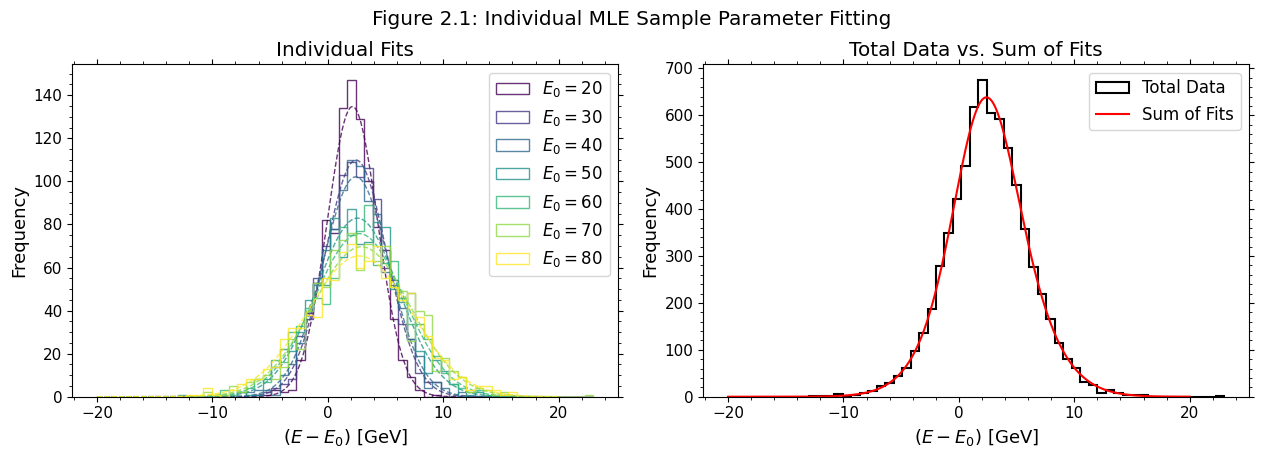

In [6]:
from s1_sol import q2

#mle_results, fig = q2.plot_unbinned_mle(df)
fig, mle_fitted_values = q2.unbinned_mle_fit_and_plot(df)

fig.savefig('../figs/Figure2.1.pdf')

- The left-hand plot above shows excellent agreement between the fitted normal distributions and the histograms, confirming the assumption of a normal distribution is valid across all $E_0$.
- The Individial fits plot also shows an increasing mean and standard deviation as the $E_0$ value increases, aligning with the observations in the first section, suggesting the MLE fitting has been effective.
- In the right-hand plot the summation of individual fits aligns very well with the histogram of the total data, with very few discrepancies such as long tails or an odd skew. This confirms the total total distribution can be modelled easily by breaking samples down into $E_0$ groups.

### 2(ii) fit trends

Using the same 'Least Squares' approach as in section *1(iv)* the fitting parameters, $\{\lambda, \Delta, a, b, c\}$, are found by fitting *Eq. 1* and *Eq. 2* to the set of $\hat{\mu}_{\rm indiv}$ and $\hat{\sigma}_{\rm indiv}$ values calculated in section *2(i)*. The same graphs are plotted using these newly found parameters and the same bootstrap procedure is used to calculate the error bands from the covariance matrix.

Fitted parameter values:
λ = 1.012 ± 0.002
Δ = 1.964 ± 0.087
a = 0.387 ± 0.059
b = 1.126 ± 0.376
c = 0.034 ± 0.008 

Saved to 'results.json'


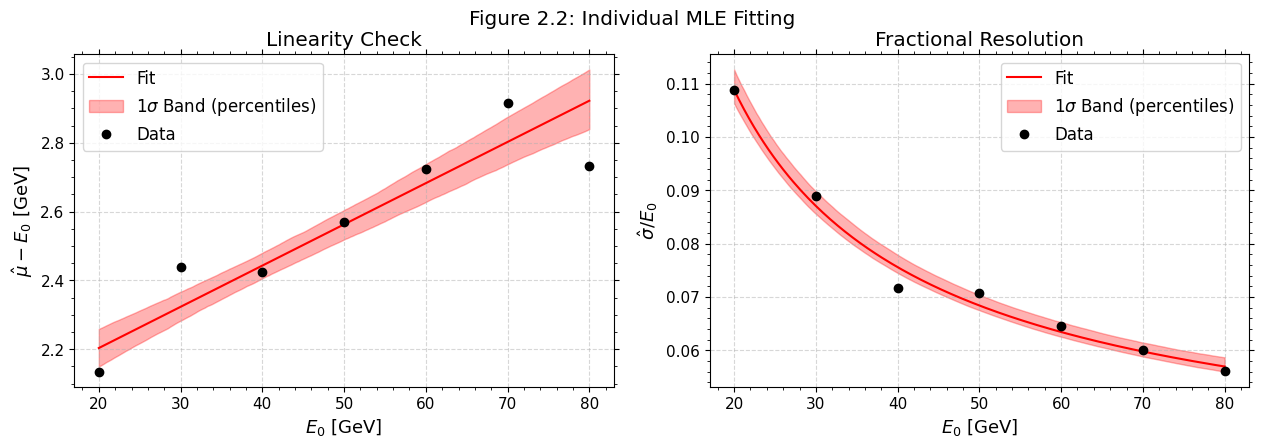

In [7]:
fig = q1.least_squares_fit_and_plot(mle_fitted_values, "individual_fits","Figure 2.2: Individual MLE Fitting")

fig.savefig("../figs/Figure2.2.pdf")

The results from the Individual MLE and sample estimate fitting are nearly identical. Parameters $\lambda$ and $\Delta$ match to 8 significant figures (errors to 3), while $a, b$, and $c$ match to 3 s.f. (errors to 1). This agreement between the non-parametric sample estimates and the Gaussian MLE confirms the data follows a normal distribution well. The same negative skew in the right hand graph's error bars is present as in *Fig. 1.4*.


## 3.) Simultaneous Fit
**10 marks**

### 3(i) The Simultaneous Likelihood
In this final step a Simultaneous Unbinned Maximum Likelihood fit is applied, instead of fitting a normal distribution to each $E_0$ value, the fit is applied to the entire dataset at once. A single likelihood function is defined as a function of all the parameters $\{\lambda, \Delta, a, b, c\}$:

$$
\mathcal{L}(\lambda, \Delta, a, b, c) = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi}\sigma(E_{0,i})} \exp\left( -\frac{(E_i - \mu(E_{0,i}))^2}{2\sigma(E_{0,i})^2} \right) \tag{11}
$$
Where the $\mu(E_{0,i})$ and $\sigma(E_{0,i})$ are given by rearranged versions of *Eq. 1* and *Eq. 2*. The negative log likelihood is then defined as:
$$
-\ln\mathcal{L}(\lambda, \Delta, a, b, c) = \sum_{i=1}^{N} \left[ \ln\left(\sigma(E_{0,i})\right) + \frac{1}{2}\frac{(E_i - \mu(E_{0,i}))^2}{\sigma(E_{0,i})^2} \right] \tag{12}, 
$$
where the $\sum_{i=1}^{N} \ln(\sqrt{2\pi})$ is removed as it is a constant, not dependent on any parameters and so just offsets the likelihood. The nll is then minimised using the `Minuit` package where `m.errordef = Minuit.LIKELIHOOD` to offset the factor of $\frac{1}{2}$ left inside the equation. In the optimisation procedure a hard limit is set to keep $a,b$ and $c$ positive, this is helps to minimiser to achieve a faster fit as in the equations $a,b$ and $c$ are all squared and hence negative values present degenerate solutions.
As in *section 1* and *2* we plot the scaled $\mu_E - E_0$ and $\sigma_E / E_0$ as a function of $E_0$, however as we fit for the final parameters, no individual $\mu_E$ or $\sigma_E$ values are plotted for each $E_0$.

Fitted parameter values:
λ = 1.012 ± 0.002
Δ = 1.964 ± 0.087
a = 0.398 ± 0.056
b = 1.066 ± 0.384
c = 0.033 ± 0.008 

Saved to 'results.json'


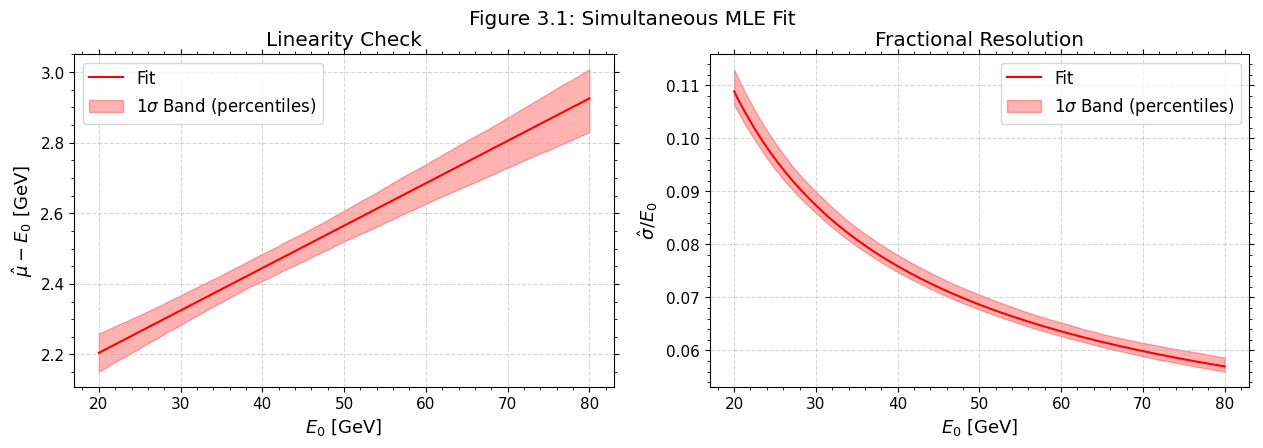

In [8]:
from s1_sol import q3

fig = q3.fit_and_plot_simultaneous_unbinned_mle(df, "simultaneous_fit","Figure 3.1: Simultaneous MLE Fit")

fig.savefig("../figs/Figure3.1.pdf")

The final simultaneous fit' parameters are slightly less close to the parameters calculated in *section 1* and *2*, agreeing to 3 s.f. for $\lambda$ and $\Delta$ (2 s.f. for errors) and 2 s.f for $a, b$ and $c$. This light disagreement is likely due to the approach of a 'global' optimisation as opposed to the previous two methods which were fitting on $\mu$ and $\sigma$ values, this allows the fit accept slightly worse individual fits but a better overall fit, which leads to slightly different values.

### 3(ii) Saving the Results
All results have been saved at each step.

### 3(iii) Comparing the Results
All of calculated and saved parameters are displayed in Figure 3.2 below, for $\lambda$ and $c$ zoomed in snapshots are provided due to the small size of the errors on the main graph.

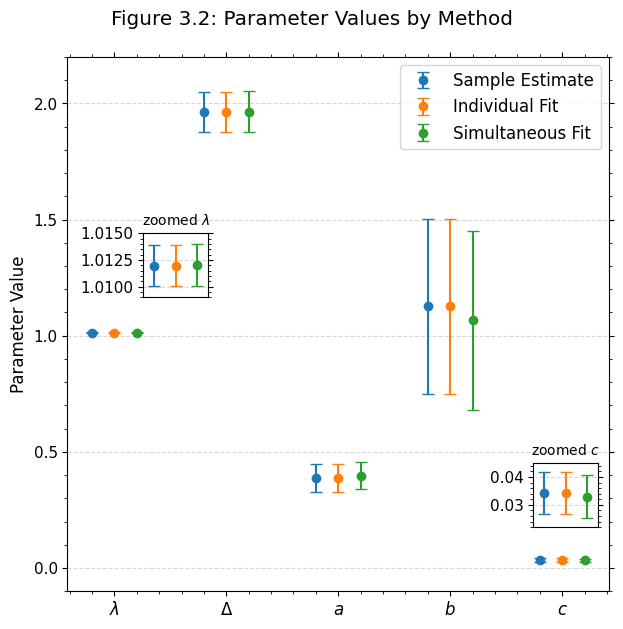

In [9]:
data = q3.load_data()
fig = q3.plot_parameter_comparison(data)

fig.savefig("../figs/Figure3.2.pdf")

*Fig. 3.2* shows the results from all three methods are well aligned, with significant overlap of the error bars across all three methods. The simultaneous fit method produces slightly different results to the sample estimate and individual fit, this can be attribtured to the 'global' nature of the simultaneous fit vs the 'local' approach of the first two fits. The error bars for $\Delta$ and $b$ have the largest values, which makes it difficult to analyse the detector's performance at lower energy levels where these two factors dominate. For context here, we take $b$ to act as a noise term independent of $E_0$.

## 4.) Bootstrap Entire Sample
**20 marks**

### 4(i)
A non-parametric bootstrap on the whole analysis chain is now applied to evaluate the reliability of the calculated results and check for bias. This is done by creating 2,500 identically sized "pseudo-datasets" by randomly sampling values for the original sample dataset with replacement. For each of 2,500 the datasets the sample estimate, individual fit and simultaneous fit methods are applied calculate the $\{\lambda, \Delta, a, b, c\}$ parameter set. The values each of the paramters are stored for each method, and are plotted in the histograms in *Fig. 4.1* below.

Running 2500 bootstrap iterations...


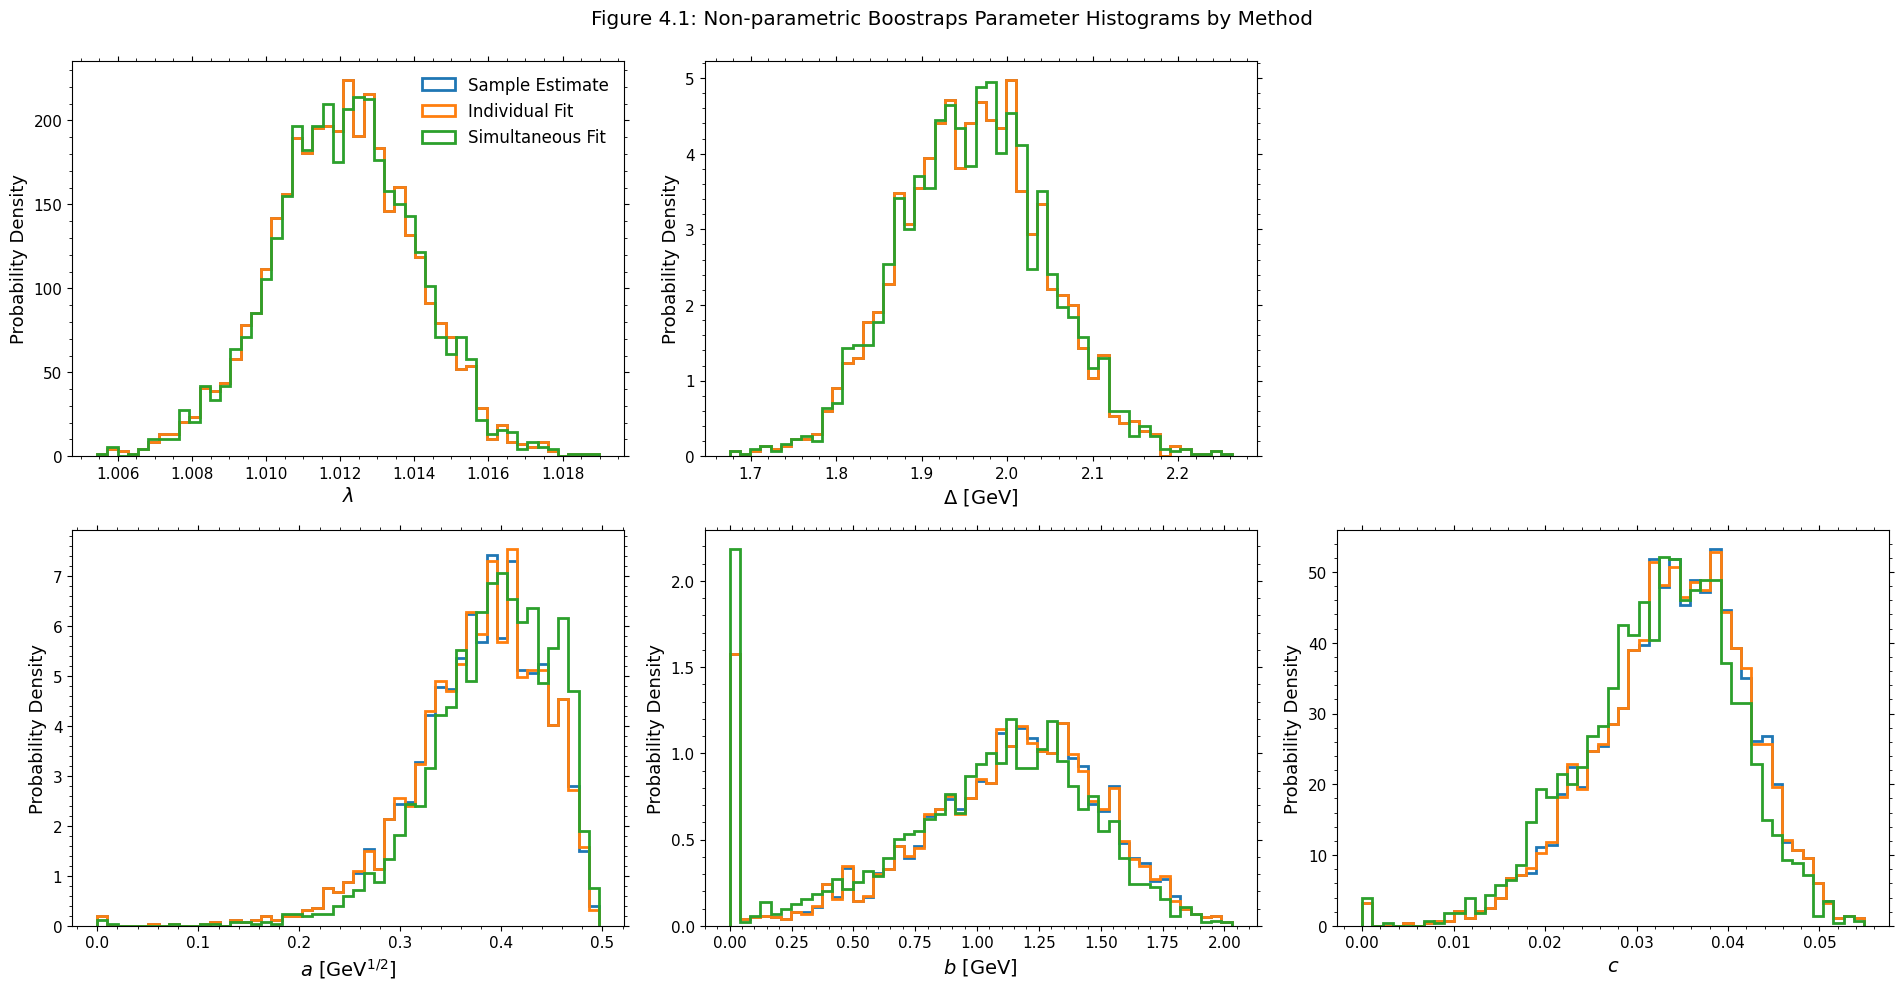

In [10]:
from s1_sol import q4

fig, boot_results = q4.boot_and_plot_hists_all_methods(df, n_boot =2500)

fig.savefig("../figs/Figure4.1.pdf")

In *Fig. 4.1* all of the five graphs show extremely strong agreement between the sample estimate and the individual fit. Even when bootstrapped 2500 times the histograms are overlapping in almost every plot, proving the approaches are statistically equivalent due to the Gaussian nature of the data. 

The green simultaneous fit tends to agree fairly strongly with the first two methods for $\lambda$ and $\Delta$, however for $a$ the simultaneous fit shows a slightly more negative skew, and for $b$ and $c$ is shows a slightly more positive skew. This further points towards the 'global' optimisation finding a "truer" minimum by fitting over the mean and sigma parameters at once rather than fitting them individually.

Another notable point is the peak in probability density in the plot of $b$ right above zero, occuring for all methods, this is likely what contributes to the large error for $b$ in *Fig. 3.2*. It is odd to see as for a good proportion of the bootstrap outcomes it suggests the best fit is essentially when $b$ is zero and there is no "noise" term.

### 4(ii) Comparing the Original Results vs. Bootstrap
From these distributions the sample mean and standard deviation of each of the bootstrapped parameters are calculated for each method. As in *section 3.2* the original parameters are plotted, now alongside the bootstrapped versions for easy comparison to see how reliable each of the methods are.

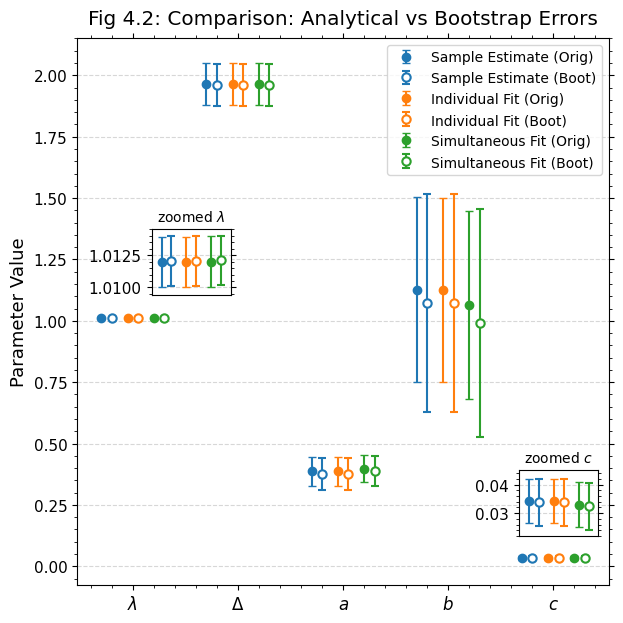

In [11]:
stats = q3.load_data()
boot_stats = q4.calculate_bootstrap_stats(boot_results)
fig = q4.plot_overlay_comparison(stats, boot_stats)

fig.savefig("../figs/Figure4.2.pdf")

*Fig 4.2* shows the error bars for the bootstrap methods for the parameters $a, b$ and $c$ are larger than their original counterparts. A potential reason for this is the use of the Hessian matrix in all of the `Iminuit` fittings, this method assumes that the parameter errors are perfectly Gaussian, which may not actually be the case. *Fig 4.1* shows this non-Gaussian behaviour through the negative skew in the $a$ and $c$ plot as well as the 'pile-up' in values at zero in the $b$ plot.

The bootstrap means tend to agree fairly well with the original means for $\lambda$ and $\Delta$, with slightly less strong agreement in $a, b$ and $c$, where the bootstrap means sitting consistently lower than the originals. It is always more difficult to estimate the width of a distribution than the mean, which is clear in this trend. As discussed just above, often statistical tools such as the Hessian tend to underestimate the width, especially if a parameter is not perfectly Gaussian, hence why when the process is repeated 2,500 times, the width parameter's means are 'pulled' down by this bias.

## 5.) Discussion of Results

**Key Findings**

The analysis above reveals significant, non-ideal biases in the detector. For the detector calibration, $\lambda \approx 1.012$, slightly above unity, showing the systematic bias increases with energy and $\Delta \approx 1.96$ GeV, a constant positive shift. The fitted width parameters ($a \approx 0.39$, $b \approx 1.1$ and $c \approx 0.033$) from *Fig. 3.1* shows the detector becomes relatively more precise at higher energy levels. The relative error drops from ~11% at 20 GeV to ~6% at 80 GeV.

**Comparison of Fitting Methods**

Statistical consistency was also noted across methods, the sample estimate and individual MLE fits agree closely, with $\lambda$ and $\Delta$ agreeing to 8 s.f., and $a, b$ and $c$ to 3 s.f., confirming the our assumptions that the data follows a Gaussian distribution. The simultaneous fit shows slightly larger differences, however this is likely due to the nature of the 'global' optimisation, which trades off individual fits for a better overall fit quality.

**Model Validation**

Generally we validated our expectations that the data followed a normal distribution, as showing in *Fig. 2.1*. We also see that the models in *Eq. 1* & *2* fit the data well as most of the data fits within the error bands, as seen in *Figs. 1.4 and 2.2*, and with the large sample size of $N=1000$ per $E_0$ value, relative uncertainties are kept fairly small.

**Observed Discrepancies**

Some discrepancies were noted resulting from the bootstrapping, *Fig. 4.2* shows that the bootstrap errors for $a, b$ and $c$ were larger than the Hessian-based errors that assume a Gaussian error distribution. This is likely due to the width parameters actually following non-Gaussian behaviour, as exhibited by error-band skew in the Fractional resolution graphs in question 1,2 & 3, and in *Fig. 4.1* by the negative skew in $a$ and $c$ and the pile-up in $b$. Furthermore, this 'pile-up' effect and large error suggest the 'noise', $b$ may be poorly constrained or generally less significant in the equation. 

Another element was that the bootstrap means for the width parameters, $a, b$ and $c$, sat consistently lower than the original estimates. This is potentially due to the nature of the Hessian included in the calculation. This tends to underestimate the width for parameters that are not strongly Gaussian, and during the bootstrap, the repeated sampling may be revealing this bias.

**Future Improvements**

Redesigned analysis could constrain $b$ differently or set it to zero, given the pile-up at zero in the distribution. For the error estimation, bootstrap errors could be used instead of Hessian, and asymmetric error bars could be used for skewed parameters. Adding to this, the number of bootstrap iterations could be increased up from 2,500 up to 10,000 for better convergence. Finally, we could investigate whether the simultaneous fit actually finds a better 'global' fit or is just getting trapped in a local minimum.